<a href="https://colab.research.google.com/github/giannayan/02_conditionals/blob/master/Winter_Olympics_CS109_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Winter Olympics CS109 Project

In [7]:
import pandas as pd

winter_df = pd.read_csv("WinterSD.csv")

print(winter_df.columns)
print(winter_df.head())

Index(['Unnamed: 0', 'Year', 'City', 'Sport', 'Discipline', 'Athlete',
       'Country', 'Gender', 'Event', 'Medal'],
      dtype='object')
   Unnamed: 0  Year      City     Sport Discipline               Athlete  \
0           0  1924  Chamonix  Biathlon   Biathlon           BERTHET, G.   
1           1  1924  Chamonix  Biathlon   Biathlon        MANDRILLON, C.   
2           2  1924  Chamonix  Biathlon   Biathlon   MANDRILLON, Maurice   
3           3  1924  Chamonix  Biathlon   Biathlon       VANDELLE, André   
4           4  1924  Chamonix  Biathlon   Biathlon  AUFDENBLATTEN, Adolf   

  Country Gender            Event   Medal  
0     FRA    Men  Military Patrol  Bronze  
1     FRA    Men  Military Patrol  Bronze  
2     FRA    Men  Military Patrol  Bronze  
3     FRA    Men  Military Patrol  Bronze  
4     SUI    Men  Military Patrol    Gold  


Number of matched countries: 29
  CountryCode      Height  Total
0         CZE  181.186635     75
1         SVK  181.015487      5
2         UKR  180.975973     11
3         POL  180.686406     27
4         FIN  180.569390    434
Observed correlation: 0.18976331757190112


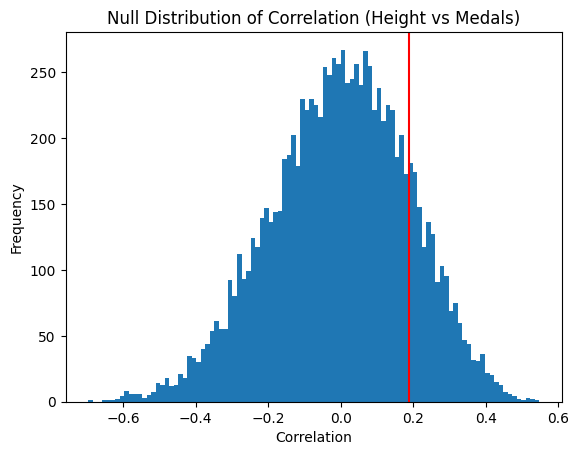

p-value: 0.3296


In [17]:
"""
Does Height Predict Winter Olympic Success?

Bootstrapping correlation between
average male height and Winter Olympic medals.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load data
height_df = pd.read_csv("Height data.csv")
winter_df = pd.read_csv("WinterSD.csv")

height_df.columns = height_df.columns.str.strip()
winter_df.columns = winter_df.columns.str.strip()

# get height data
height_df = height_df[["cca3", "meanHeightMale"]]

height_df = height_df.rename(columns={
    "cca3": "CountryCode",
    "meanHeightMale": "Height"
})

# compute total medals per county
medal_winners = winter_df[winter_df["Medal"].notna()]

medals_by_country = (
    medal_winners
    .groupby("Country")
    .size()
    .reset_index(name="Total")
)

# Rename Country to CountryCode
medals_by_country = medals_by_country.rename(columns={
    "Country": "CountryCode"
})

# merge the datasets so each row represents one country with both height + total medals

merged = pd.merge(
    height_df,
    medals_by_country,
    on="CountryCode",
    how="inner"
)

merged = merged.dropna()

print("Number of matched countries:", len(merged))
print(merged.head())


def samplestats(df):
    return np.corrcoef(df["Height"], df["Total"])[0, 1]

# observed correlation
observed_corr = samplestats(merged)
print("Observed correlation:", observed_corr)

# bootstrap function
def bootstrap():

    distribution = []

    for i in range(10000):

        shuffled_medals = np.random.permutation(merged["Total"])

        simulated_df = merged.copy()
        simulated_df["Total"] = shuffled_medals

        corr = samplestats(simulated_df)

        distribution.append(corr)

    return distribution

corr_dist = bootstrap()

# plots
plt.hist(corr_dist, bins=100)
plt.axvline(x=observed_corr, color='r')
plt.title("Null Distribution of Correlation (Height vs Medals)")
plt.xlabel("Correlation")
plt.ylabel("Frequency")
plt.show()

# p-value
count = 0

for corr in corr_dist:
    if abs(corr) >= abs(observed_corr):
        count += 1

p_val = count / len(corr_dist)

print("p-value:", p_val)